# Phase IV — Comparison & Evaluation
Compares the Faber baseline strategy against the LightGBM ML strategy.

Metrics: CAGR, Sharpe ratio, maximum drawdown, standard deviation.

Period: October 2010 - August 2024.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyfolio as pf

faber_raw = pd.read_csv('../faber_returns.csv', parse_dates=['date'], index_col='date')['return']
ml_raw    = pd.read_csv('../ml_returns.csv',    parse_dates=['date'], index_col='date')['return']

# Trim to overlapping period (ML is shifted +1 month vs Faber after lookahead fix)
start = max(faber_raw.index.min(), ml_raw.index.min())
end   = min(faber_raw.index.max(), ml_raw.index.max())
faber = faber_raw.loc[start:end]
ml    = ml_raw.loc[start:end]

c:\Users\ideac\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyfolio\pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


## Step 1: Performance Metrics

In [2]:
macro = pd.read_csv('../cleaned_macro.csv', index_col=0, parse_dates=True)
tb3ms_monthly = (macro['TB3MS'] / 100 / 12).loc[faber.index[0]:faber.index[-1]]
RISK_FREE_MONTHLY = tb3ms_monthly.reindex(faber.index).mean()
print(f'Risk-free rate (monthly avg): {RISK_FREE_MONTHLY:.6f}  ({RISK_FREE_MONTHLY*12:.2%} annualised)')

def cagr(returns):
    n_years = len(returns) / 12
    total_return = (1 + returns).prod()
    return total_return ** (1 / n_years) - 1

def sharpe(returns, rf=RISK_FREE_MONTHLY):
    excess = returns - rf
    return (excess.mean() / excess.std()) * np.sqrt(12)

def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

def std_dev(returns):
    return returns.std() * np.sqrt(12)

metrics = pd.DataFrame({
    'Faber Baseline': [
        f'{cagr(faber):.2%}',
        f'{sharpe(faber):.2f}',
        f'{max_drawdown(faber):.2%}',
        f'{std_dev(faber):.2%}',
    ],
    'ML Strategy': [
        f'{cagr(ml):.2%}',
        f'{sharpe(ml):.2f}',
        f'{max_drawdown(ml):.2%}',
        f'{std_dev(ml):.2%}',
    ],
}, index=['CAGR', 'Sharpe Ratio', 'Max Drawdown', 'Std Deviation'])

print(metrics.to_string())

Risk-free rate (monthly avg): 0.000990  (1.19% annualised)
              Faber Baseline ML Strategy
CAGR                   5.03%       4.33%
Sharpe Ratio            0.62        0.37
Max Drawdown         -11.36%     -18.21%
Std Deviation          6.31%       9.56%


## Step 2: Cumulative Returns Chart

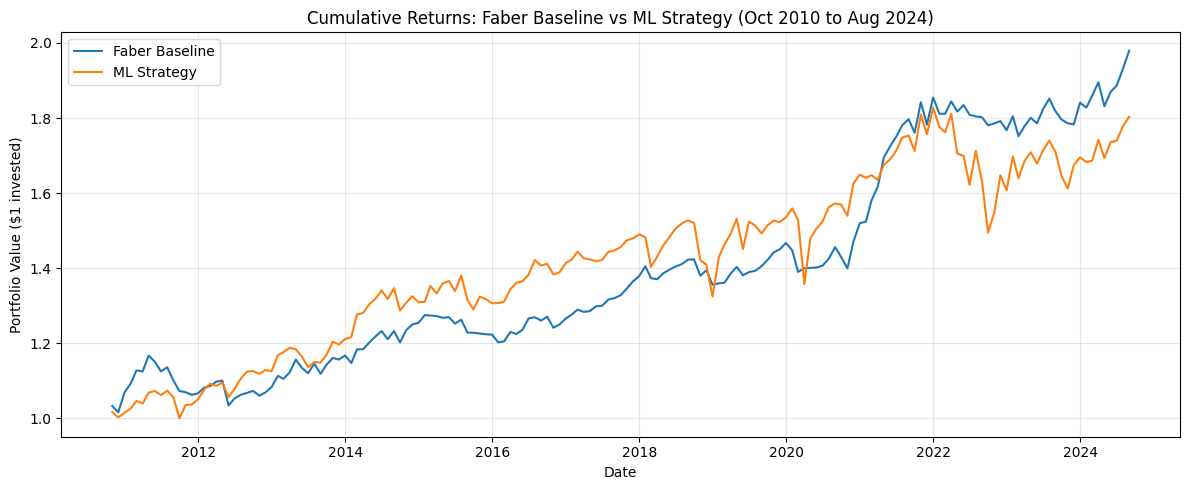

In [3]:
faber_cumulative = (1 + faber).cumprod()
ml_cumulative    = (1 + ml).cumprod()

period_label = f"{start.strftime('%b %Y')} to {end.strftime('%b %Y')}"

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(faber_cumulative.index, faber_cumulative, label='Faber Baseline', linewidth=1.5)
ax.plot(ml_cumulative.index,    ml_cumulative,    label='ML Strategy',    linewidth=1.5)
ax.set_title(f'Cumulative Returns: Faber Baseline vs ML Strategy ({period_label})', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($1 invested)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('../figures/cumulative_returns.png', dpi=150)
plt.show()

## Step 3: Pyfolio Report

=== Faber Baseline ===


c:\Users\ideac\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '180.175%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2010-10-31
End date,2024-08-31
Total months,7
,Backtest
Annual return,180.175%
Cumulative returns,97.929%
Annual volatility,28.918%
Sharpe ratio,3.71
Calmar ratio,15.86
Stability,0.93
Max drawdown,-11.357%


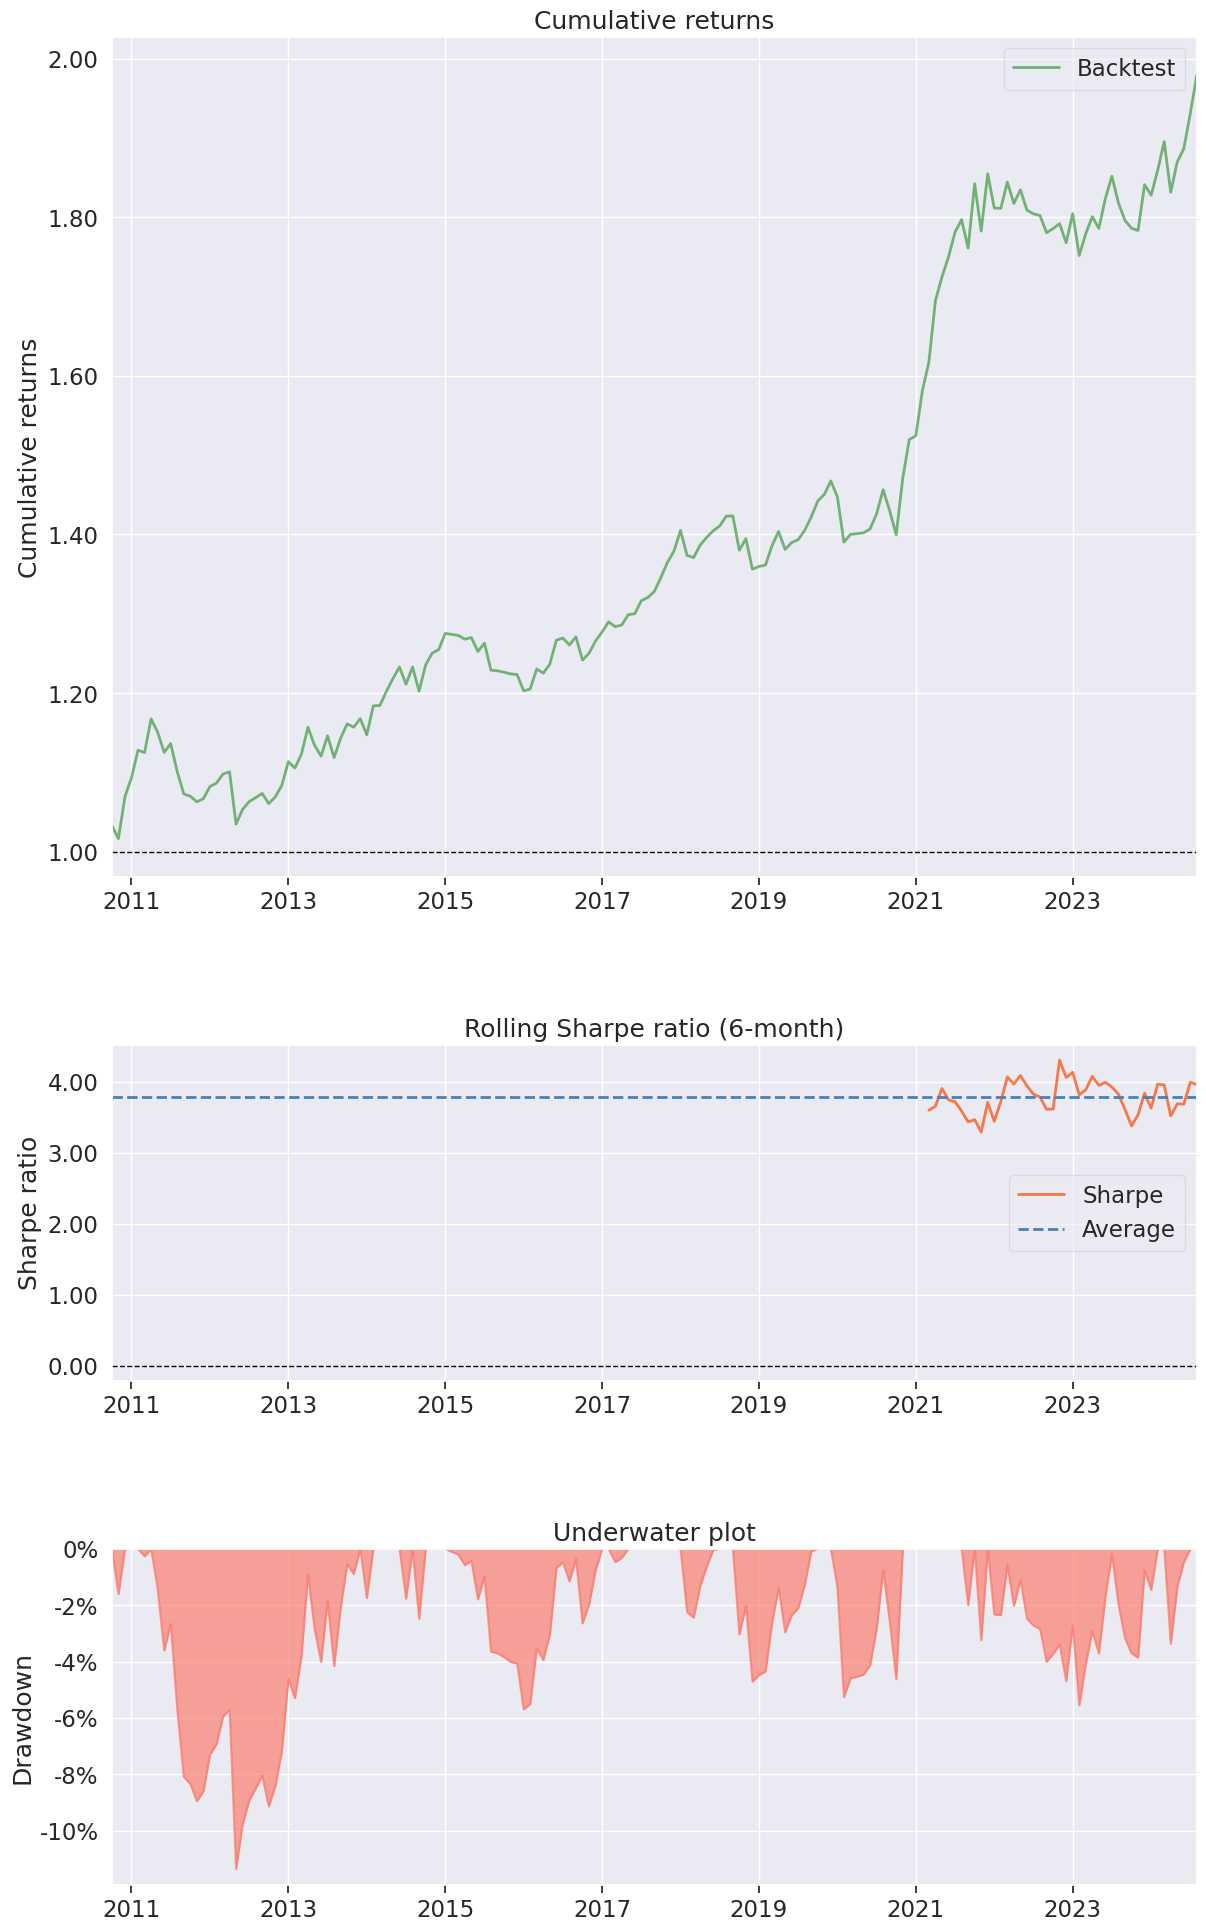

In [4]:
print('=== Faber Baseline ===')
pf.create_simple_tear_sheet(faber)

=== ML Strategy ===


c:\Users\ideac\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '143.496%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2010-10-31
End date,2024-08-31
Total months,7
,Backtest
Annual return,143.496%
Cumulative returns,80.355%
Annual volatility,43.805%
Sharpe ratio,2.25
Calmar ratio,7.88
Stability,0.92
Max drawdown,-18.211%


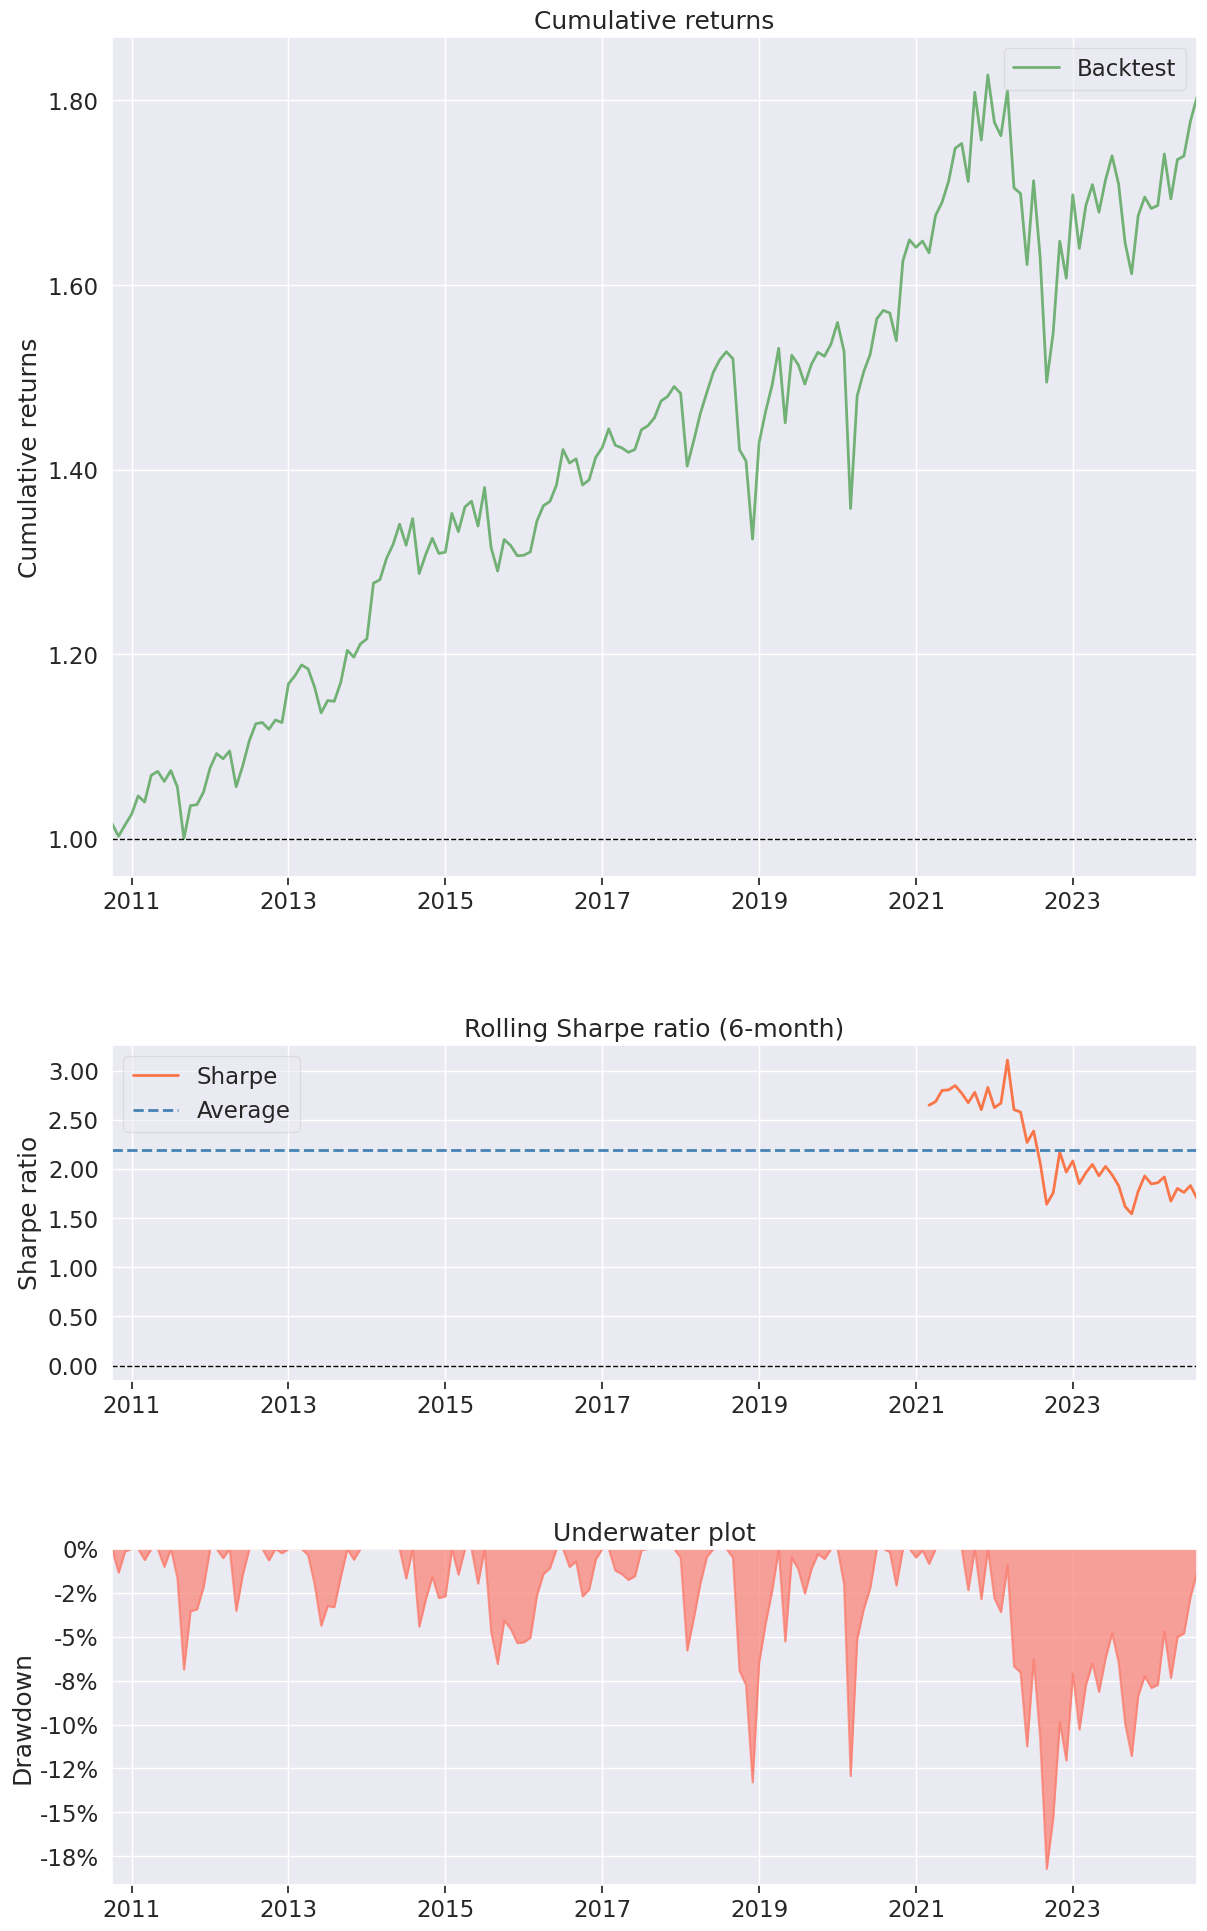

In [5]:
print('=== ML Strategy ===')
pf.create_simple_tear_sheet(ml)